<a href="https://colab.research.google.com/github/alfinoktviaan/DataScience_240401010282_AlfinOktavian/blob/main/Pertemuan13_AlfinOktavian_240401010282.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
NAMA: Alfin Oktavian

Kelas: IF403

NIM: 240401010282

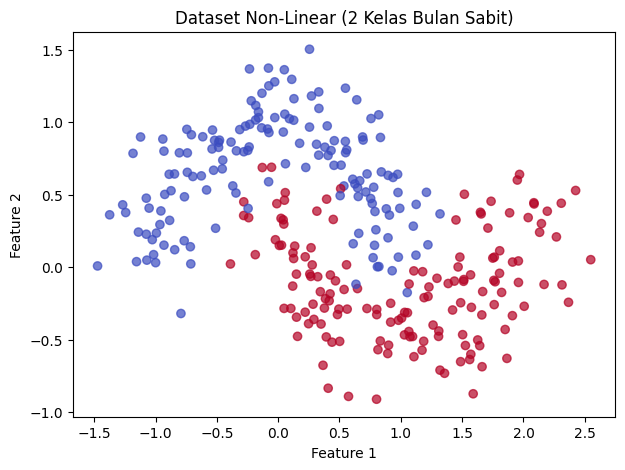

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# Membuat dataset non-linear
X, y = make_moons(
    n_samples=300,
    noise=0.2,
    random_state=42
)

# Visualisasi dataset
plt.figure(figsize=(7,5))
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap='coolwarm',
    alpha=0.7
)

plt.title('Dataset Non-Linear (2 Kelas Bulan Sabit)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [2]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Membagi data menjadi data latih dan data uji
X_tr, X_te, y_tr, y_te = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Membangun arsitektur Neural Network
model = Sequential([
    Dense(16, activation='relu', input_shape=(2,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Konfigurasi model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Menampilkan arsitektur model
model.summary()

# Melatih model
history = model.fit(
    X_tr,
    y_tr,
    epochs=30,
    validation_split=0.2,
    verbose=0
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

Akurasi pada data uji: 0.900


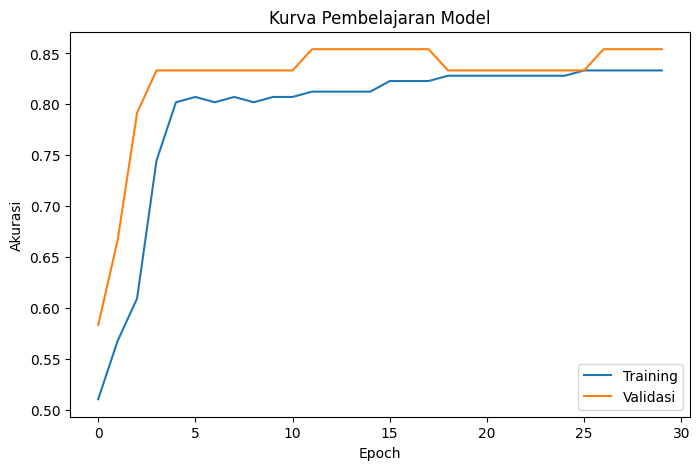

In [3]:
import matplotlib.pyplot as plt

# Evaluasi model pada data uji
loss, acc = model.evaluate(X_te, y_te, verbose=0)

print(f"Akurasi pada data uji: {acc:.3f}")

# Visualisasi kurva akurasi
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validasi')

plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.title('Kurva Pembelajaran Model')
plt.legend()

plt.show()

In [5]:
ulasan = [
    # Positif
    "Barangnya bagus banget, pengiriman cepat",
    "Sangat puas, akan beli lagi",
    "Recommended, harga sesuai kualitas",
    "Produknya berkualitas dan sesuai deskripsi",
    "Pengemasan rapi dan aman",
    "Respon penjual sangat cepat",
    "Barang original dan berfungsi dengan baik",
    "Pengiriman lebih cepat dari perkiraan",
    "Harga murah, kualitas mantap",
    "Pelayanan sangat memuaskan",
    "Barang sesuai foto dan deskripsi",
    "Sangat direkomendasikan untuk dibeli",
    "Kualitas premium, saya suka",
    "Produk bekerja dengan sangat baik",
    "Seller ramah dan membantu",
    "Pengalaman belanja sangat menyenangkan",
    "Barang diterima dalam kondisi sempurna",
    "Sangat puas dengan kualitas produk",
    "Mantap, sesuai harapan",
    "Terima kasih, produk sangat bagus",

    # Negatif
    "Kualitas jelek, tidak sesuai deskripsi",
    "Kecewa, barang rusak saat sampai",
    "Buruk sekali, tidak sesuai ekspektasi",
    "Pengiriman sangat lambat",
    "Barang cacat dan tidak bisa digunakan",
    "Kemasan rusak saat diterima",
    "Sangat mengecewakan",
    "Produk palsu dan kualitas buruk",
    "Tidak akan beli lagi",
    "Penjual tidak merespon komplain",
    "Barang tidak sesuai gambar",
    "Kualitas sangat buruk",
    "Harga mahal tetapi kualitas jelek",
    "Produk rusak setelah satu hari",
    "Tidak puas dengan pelayanan",
    "Pengiriman terlambat beberapa hari",
    "Barang kurang lengkap",
    "Sangat kecewa dengan pembelian ini",
    "Produk tidak berfungsi sama sekali",
    "Tidak direkomendasikan"
]

label = [
    # Positif = 1
    1,1,1,1,1,1,1,1,1,1,
    1,1,1,1,1,1,1,1,1,1,

    # Negatif = 0
    0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0
]

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Membuat objek TF-IDF
tfidf = TfidfVectorizer()

# Mengubah teks menjadi matriks TF-IDF
X_text = tfidf.fit_transform(ulasan)

# Menampilkan jumlah kata unik
print("Jumlah kata unik:", len(tfidf.get_feature_names_out()))

# Menampilkan 10 kata pertama
print("\n10 Kata Pertama:")
print(tfidf.get_feature_names_out()[:10])

Jumlah kata unik: 88

10 Kata Pertama:
['akan' 'aman' 'bagus' 'baik' 'banget' 'barang' 'barangnya' 'beberapa'
 'bekerja' 'belanja']


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Membagi data menjadi data latih dan data uji
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
    X_text,
    label,
    test_size=0.2,
    random_state=42
)

# Membuat model Logistic Regression
model_sentimen = LogisticRegression()

# Melatih model
model_sentimen.fit(Xt_tr, yt_tr)

# Menguji akurasi model
akurasi = model_sentimen.score(Xt_te, yt_te)

print(f"Akurasi model sentimen: {akurasi:.3f}")

# ======================
# Menguji kalimat baru
# ======================

kalimat_baru = [
    "Barangnya sangat bagus dan berkualitas"
]

pred = model_sentimen.predict(
    tfidf.transform(kalimat_baru)
)

print("Prediksi Sentimen:",
      "Positif" if pred[0] == 1 else "Negatif")

Akurasi model sentimen: 0.500
Prediksi Sentimen: Positif
